# PADD 3 Distillate Fuel Oil — Supply & Disposition Pipeline

## Overview

This pipeline ingests monthly EIA petroleum supply and disposition data for 
PADD 3 (Gulf Coast) Distillate Fuel Oil — the primary diesel market that 
Sunoco's Supply & Trading team monitors for procurement decisions, 
arbitrage opportunities, and supply/demand positioning.

**Data source:** U.S. Energy Information Administration (EIA) Open Data API  
**Product:** Distillate Fuel Oil (diesel + heating oil)  
**Region:** PADD 3 — Gulf Coast (Texas, Louisiana, Mississippi, Alabama, Arkansas)  
**Unit:** Thousand Barrels per Day (MBBL/D)  
**Coverage:** January 2015 — most recent available month  

### Pipeline Architecture

The pipeline follows a medallion architecture with three layers:

- **Bronze** — Raw API responses saved as JSON, no transformations
- **Silver** — Cleaned, normalized long-format CSV (one row per month per series)
- **Gold** — Annual averages pivoted to wide format for analysis and visualization

## Data Mapping

The following EIA series were identified from the PADD 3 Distillate Fuel Oil 
Supply and Disposition table at:  
https://www.eia.gov/dnav/pet/pet_sum_snd_d_r30_mbblpd_m_cur.htm

| Human-Readable Name | EIA Series ID | Side |
|---|---|---|
| Refinery and Blender Net Production | PET.MDIRPP32.M | Supply |
| Imports | PET.MDIIMP32.M | Supply |
| Net Receipts | PET.MDINRP32.M | Supply |
| Adjustments | PET.M_EPD0_VUA_R30_2.M | Supply |
| Stock Change | PET.MDISCP32.M | Disposition |
| Exports | PET.MDIEXP32.M | Disposition |
| Products Supplied | PET.MDIUPP32.M | Disposition |

### Notes on Data Availability

- **Biofuels Plant Net Production** — excluded. PADD 3 reports zero biofuel-derived 
distillate across all periods. No dedicated API series exists for this product/region combination.
- **Adjustments** — data available January 2015 through December 2020 only. 
The EIA discontinued this series after 2020. Gold layer shows NaN for 2021 onward.
- **Imports** — sparse data (73 of 133 months). PADD 3 rarely imports distillate 
as it is a large net exporter. Missing months represent zero or unreported imports.

## Architecture & Design Choices

**Medallion architecture (Bronze/Silver/Gold)** — Each layer has one job. Bronze preserves raw API responses so transformations can be replayed without re-hitting the API. Silver cleans and normalizes. Gold aggregates for analysis.

**Long format in Silver, wide in Gold** — Silver's one-row-per-month-per-series layout keeps the data composable for any grouping or join. Gold pivots to annual columns for direct readability and charting.

**Partial years excluded from analysis** — 2026 contains January data only. A one-month "annual average" is misleading, so the chart and analysis cover 2015–2025.

**API key in `.env`, never committed** — `.env` is gitignored; a `.env.example` template with the variable name is committed instead.

## Pipeline Instructions

Each layer can be run individually from the project root, or sequentially below.

```bash
# Run individually from terminal
python3 -m src.bronze
python3 -m src.silver
python3 -m src.gold

# Run tests
python3 -m pytest tests/ -v
```


In [1]:
import sys
import os

# Add project root to path so src imports work from the notebook
sys.path.insert(0, os.path.abspath(".."))

from src.bronze import run_bronze
from src.silver import run_silver
from src.gold import run_gold

print("All modules imported successfully.")

/Users/karanbassi/Desktop/Sunoco LP Sim/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All modules imported successfully.


In [2]:
# Run full pipeline
run_bronze()
print()
run_silver()
print()
run_gold()

Fetching: Refinery and Blender Net Production (PET.MDIRPP32.M)
  133 records saved to /Users/karanbassi/Desktop/Sunoco LP Sim/data/bronze/refinery_and_blender_net_production.json
Fetching: Imports (PET.MDIIMP32.M)
  73 records saved to /Users/karanbassi/Desktop/Sunoco LP Sim/data/bronze/imports.json
Fetching: Net Receipts (PET.MDINRP32.M)
  133 records saved to /Users/karanbassi/Desktop/Sunoco LP Sim/data/bronze/net_receipts.json
Fetching: Adjustments (PET.M_EPD0_VUA_R30_2.M)
  72 records saved to /Users/karanbassi/Desktop/Sunoco LP Sim/data/bronze/adjustments.json
Fetching: Stock Change (PET.MDISCP32.M)
  133 records saved to /Users/karanbassi/Desktop/Sunoco LP Sim/data/bronze/stock_change.json
Fetching: Exports (PET.MDIEXP32.M)
  133 records saved to /Users/karanbassi/Desktop/Sunoco LP Sim/data/bronze/exports.json
Fetching: Products Supplied (PET.MDIUPP32.M)
  133 records saved to /Users/karanbassi/Desktop/Sunoco LP Sim/data/bronze/products_supplied.json

Bronze layer complete.

Proc

,year,Adjustments,Exports,Imports,Net Receipts,Products Supplied,Refinery and Blender Net Production,Stock Change
0,2015,14.083333,1019.916667,12.700000,-1014.250000,799.416667,2814.250000,5.583333
1,2016,25.250000,1017.333333,15.000000,-941.916667,779.166667,2710.333333,7.250000
2,2017,19.416667,1201.250000,14.700000,-878.666667,786.916667,2826.166667,-9.000000
3,2018,23.666667,1151.166667,11.250000,-947.083333,865.583333,2925.166667,-7.916667
4,2019,21.250000,1135.833333,9.833333,-920.333333,895.333333,2929.166667,3.750000
5,2020,19.916667,1076.250000,1.750000,-959.333333,707.083333,2744.333333,22.000000
6,2021,NaN,982.333333,13.750000,-914.583333,812.333333,2665.416667,-39.166667
7,2022,NaN,1108.000000,3.000000,-928.416667,902.083333,2935.333333,-2.083333
8,2023,NaN,987.083333,4.571429,-902.000000,959.500000,2862.583333,16.583333
9,2024,NaN,1130.500000,1.125000,-932.000000,850.166667,2907.666667,-3.916667


## Test Results

Unit tests validate transformation logic using in-memory data.  
Validation tests check data reasonableness against the actual gold layer output.

In [3]:
import subprocess

result = subprocess.run(
    ["python3", "-m", "pytest", "tests/", "-v"],
    capture_output=True,
    text=True,
    cwd=os.path.abspath("..")
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

============================= test session starts ==============================
platform darwin -- Python 3.9.6, pytest-8.4.2, pluggy-1.6.0 -- /Users/karanbassi/Desktop/Sunoco LP Sim/.venv/bin/python3
cachedir: .pytest_cache
rootdir: /Users/karanbassi/Desktop/Sunoco LP Sim
plugins: anyio-4.12.1
collecting ... collected 14 items

tests/test_silver.py::TestCleanSeries::test_period_parsed_to_datetime PASSED [  7%]
tests/test_silver.py::TestCleanSeries::test_value_cast_to_float PASSED   [ 14%]
tests/test_silver.py::TestCleanSeries::test_null_values_dropped PASSED   [ 21%]
tests/test_silver.py::TestCleanSeries::test_schema_correct PASSED        [ 28%]
tests/test_silver.py::TestCleanSeries::test_sorted_by_period PASSED      [ 35%]
tests/test_silver.py::TestCleanSeries::test_non_numeric_value_coerced_to_null_and_dropped PASSED [ 42%]
tests/test_validation.py::test_gold_file_exists PASSED                   [ 50%]
tests/test_validation.py::test_minimum_year_coverage PASSED              [ 57%]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load gold data
gold = pd.read_csv("../data/gold/distillate_padd3_annual.csv")

# Exclude 2026 — incomplete year (January only)
gold = gold[gold["year"] < 2026].copy()

print(gold.to_string())

Matplotlib is building the font cache; this may take a moment.


    year  Adjustments      Exports    Imports  Net Receipts  Products Supplied  Refinery and Blender Net Production  Stock Change
0   2015    14.083333  1019.916667  12.700000  -1014.250000         799.416667                          2814.250000      5.583333
1   2016    25.250000  1017.333333  15.000000   -941.916667         779.166667                          2710.333333      7.250000
2   2017    19.416667  1201.250000  14.700000   -878.666667         786.916667                          2826.166667     -9.000000
3   2018    23.666667  1151.166667  11.250000   -947.083333         865.583333                          2925.166667     -7.916667
4   2019    21.250000  1135.833333   9.833333   -920.333333         895.333333                          2929.166667      3.750000
5   2020    19.916667  1076.250000   1.750000   -959.333333         707.083333                          2744.333333     22.000000
6   2021          NaN   982.333333  13.750000   -914.583333         812.333333            

## Market Analysis

### PADD 3 Distillate Supply and Disposition — 2015 to 2025

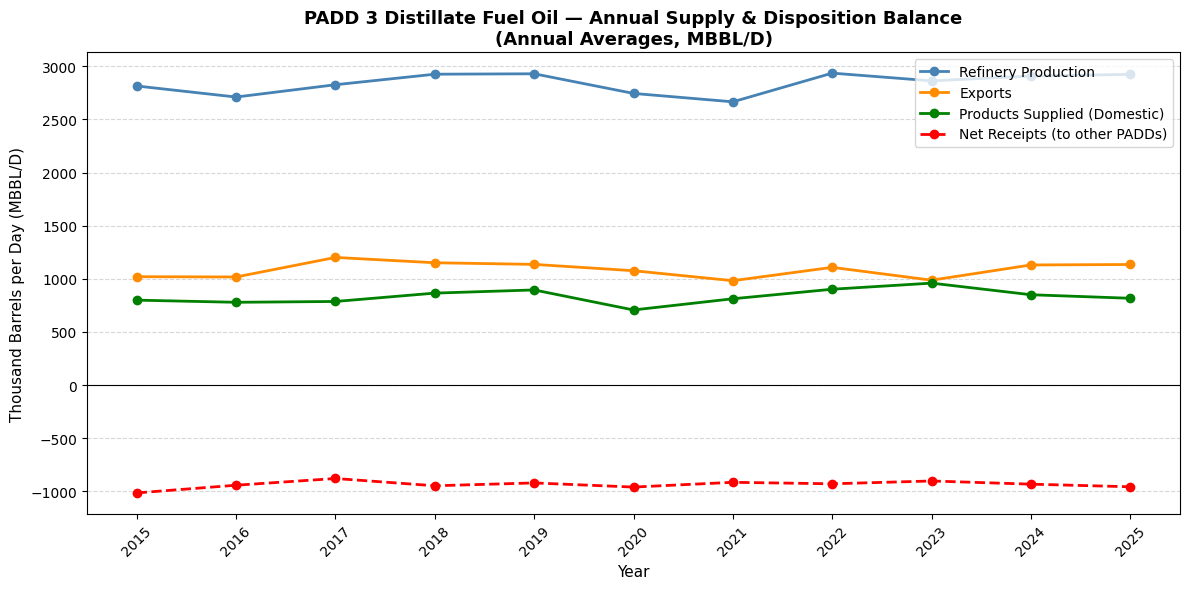

Chart saved.


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

years = gold["year"]

ax.plot(years, gold["Refinery and Blender Net Production"],
        marker="o", linewidth=2, label="Refinery Production", color="steelblue")
ax.plot(years, gold["Exports"],
        marker="o", linewidth=2, label="Exports", color="darkorange")
ax.plot(years, gold["Products Supplied"],
        marker="o", linewidth=2, label="Products Supplied (Domestic)", color="green")
ax.plot(years, gold["Net Receipts"],
        marker="o", linewidth=2, label="Net Receipts (to other PADDs)", color="red",
        linestyle="--")

ax.set_title("PADD 3 Distillate Fuel Oil — Annual Supply & Disposition Balance\n(Annual Averages, MBBL/D)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Thousand Barrels per Day (MBBL/D)", fontsize=11)
ax.set_xticks(years)
ax.xaxis.set_tick_params(rotation=45)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("../data/gold/padd3_distillate_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

### Hypothesis: PADD 3 Distillate Supply/Demand Balance (2015–2025)

#### Refinery Production — Stable with Disruption Events
Production has held steady at approximately 2,850 MBBL/D over the decade, with two disruptions: COVID-19 demand destruction in 2020 and the February 2021 Texas freeze, which pushed output to its decade low of 2,665 MBBL/D. Both recovered quickly, confirming the structural resilience of Gulf Coast refining.

#### Exports — The Dominant Trend
Exports grew from 1,020 MBBL/D in 2015 to 1,135 MBBL/D in 2025 — roughly 11% over the decade — with the sharpest jump in 2017 as US shale-driven capacity expansion met growing Latin American diesel demand. By 2025, exports represent approximately 39% of refinery production, confirming PADD 3 as the primary diesel export hub for the Americas.

#### Domestic Demand — Flat to Declining
Products Supplied has averaged ~850 MBBL/D with no growth trend — it collapsed in 2020 (COVID), peaked at 960 MBBL/D in 2023, and fell back to 817 MBBL/D in 2025. Domestic demand in PADD 3 is not growing; incremental production is flowing to export markets.

#### Net Receipts — PADD 3 as National Supplier
Net Receipts are negative every year, consistently in the -900 to -1,050 MBBL/D range, meaning PADD 3 continuously ships roughly 1 million barrels per day to other US regions via pipeline. Combined with exports, PADD 3 simultaneously supplies both domestic and international markets.

#### Overall Balance Assessment
PADD 3 runs a structural surplus — production consistently exceeds the sum of domestic consumption and regional pipeline outflows, with exports absorbing the difference. For Supply & Trading, the key lever is export competitiveness: monitoring refinery run rates, Latin American demand, and Gulf Coast export arb versus domestic rack prices drives the most actionable procurement positioning.